# Coronal Holes — Implementation / 구현

**Paper**: Cranmer, S. R., "Coronal Holes", *Living Reviews in Solar Physics*, **6**, 3 (2009). DOI: [10.12942/lrsp-2009-3](https://doi.org/10.12942/lrsp-2009-3)

This notebook reproduces the key quantitative concepts from Cranmer's review of coronal holes. We focus on five self-contained numerical exercises:

1. **Parker isothermal wind equation** — critical point and outflow solution in a CH base plasma
2. **Hydrostatic vs. expanding atmosphere** — why CHs are dark (density falloff with and without wind)
3. **Flux-tube superradial expansion** — Wang-Sheeley-style $f_\mathrm{ss}$ vs. wind speed relation
4. **Alfvén-wave energy flux** — do the observed wave amplitudes supply enough energy?
5. **Ion-cyclotron resonance map** — $(\omega, B)$ parameter space for heavy-ion heating

이 노트북은 Cranmer의 코로나 홀 리뷰의 핵심 정량 개념을 재현합니다. 다섯 개의 독립된 수치 연습을 다룹니다:
1. **Parker 등온풍 방정식** — CH 기저 플라즈마에서의 임계점과 유출 해
2. **정수압 vs. 팽창 대기** — CH가 왜 어두운가 (풍이 있을 때와 없을 때의 밀도 감소)
3. **자속관 초발산** — Wang-Sheeley식 $f_\mathrm{ss}$ vs. 풍속 관계
4. **Alfvén파 에너지 플럭스** — 관측 진폭이 필요 에너지를 공급하는가?
5. **이온-사이클로트론 공명 지도** — 중이온 가열을 위한 $(\omega, B)$ 매개변수 공간

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import solve_ivp

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Physical constants (SI)
G_CONST = 6.67430e-11        # gravitational constant, m^3 kg^-1 s^-2
M_SUN = 1.989e30             # solar mass, kg
R_SUN = 6.9634e8             # solar radius, m
K_B = 1.380649e-23           # Boltzmann constant, J/K
M_P = 1.6726219e-27          # proton mass, kg
MU_0 = 1.2566370614e-6       # vacuum permeability, H/m
E_CHARGE = 1.602176634e-19   # elementary charge, C

GM_SUN = G_CONST * M_SUN
print(f'GM_sun / R_sun      = {GM_SUN / R_SUN:.3e} m^2/s^2')
print(f'Escape speed at Rsun = {np.sqrt(2*GM_SUN/R_SUN)/1e3:.1f} km/s')

GM_sun / R_sun      = 1.906e+11 m^2/s^2
Escape speed at Rsun = 617.5 km/s


## Part 1: Parker Isothermal Wind Solution / Parker 등온풍 해

**English.** The Parker wind equation for an isothermal atmosphere is

$$ \frac{1}{u}\frac{du}{dr}(u^2 - a^2) = \frac{2a^2}{r} - \frac{GM_\odot}{r^2} $$

Transonic critical point: $r_c = GM_\odot / (2a^2)$ where $u = a$. The transonic solution is obtained by integrating the Bernoulli-like integral

$$ \frac{u^2}{2} - a^2 \ln u + a^2 \ln(r^2) + \frac{GM_\odot}{r} = C_\mathrm{crit} $$

For each radius we solve for $u(r)$ numerically using `brentq`. Below $r_c$ pick the subsonic root; above $r_c$ pick the supersonic root.

**한국어.** Parker 등온풍 방정식은 위와 같습니다. 천이 임계점 $r_c = GM_\odot/(2a^2)$에서 $u=a$. Bernoulli 적분을 이용해 각 반지름에서 `brentq`로 수치적으로 $u(r)$을 해결. $r_c$ 아래는 아음속 가지, 위는 초음속 가지를 선택.

In [3]:
def parker_wind_solution(T_base, r_array):
    """Solve the Parker transonic isothermal wind.

    Integrates the momentum equation to obtain the Bernoulli-like invariant
    (u^2/2) - a^2 ln u - 2 a^2 ln r - GM/r = C_crit, then picks the subsonic
    root below the critical radius and the supersonic root above.

    Args:
        T_base: isothermal corona temperature, K.
        r_array: array of radii in meters (must span critical point).

    Returns:
        u_array: outflow speed, m/s.
        r_crit: critical radius, m.
        a: isothermal sound speed, m/s.
    """
    # Fully ionized hydrogen: mean mass per particle = m_p/2
    a = np.sqrt(2 * K_B * T_base / M_P)
    r_crit = GM_SUN / (2 * a**2)
    C_crit = 0.5 * a**2 - a**2 * np.log(a) - 2 * a**2 * np.log(r_crit) - GM_SUN / r_crit

    def bernoulli(u, r):
        return 0.5 * u**2 - a**2 * np.log(u) - 2 * a**2 * np.log(r) - GM_SUN / r - C_crit

    u_array = np.zeros_like(r_array)
    for i, r in enumerate(r_array):
        if r < r_crit:
            u_array[i] = brentq(bernoulli, 1e-3, a - 1e-3, args=(r,))
        elif r > r_crit:
            u_array[i] = brentq(bernoulli, a + 1e-3, 20 * a, args=(r,))
        else:
            u_array[i] = a
    return u_array, r_crit, a

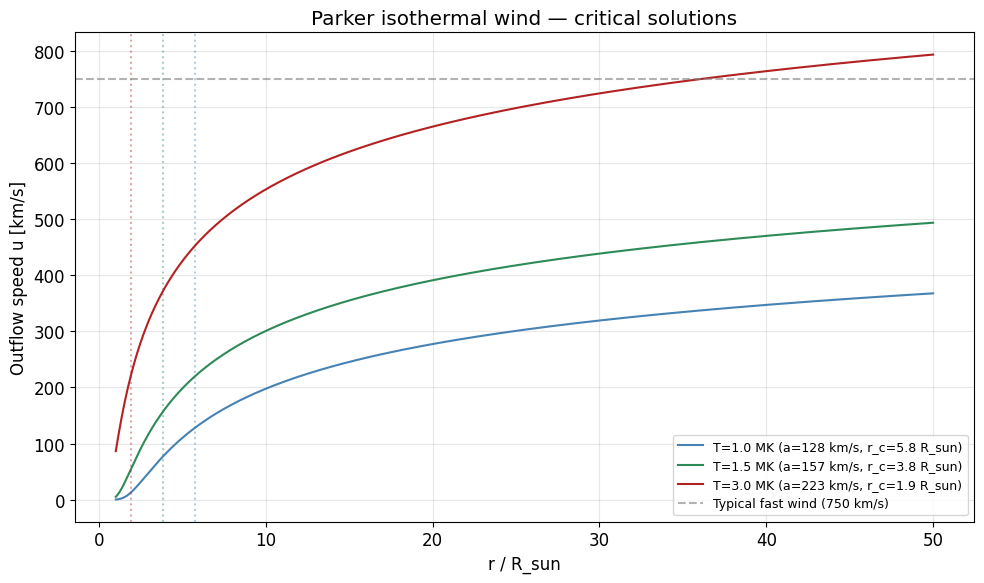


Punch line / 결론:
  A purely isothermal Parker wind at 1-1.5 MK saturates well below 700 km/s.
  Additional heating beyond simple thermal conduction is REQUIRED to reach the observed
  fast-wind speeds — exactly what WTD or RLO mechanisms must supply.
  등온 Parker 풍은 1–1.5 MK에서 700 km/s에 한참 미치지 못함.
  관측된 고속풍에 도달하려면 단순 열전도를 넘는 가열이 반드시 필요 — WTD/RLO가 공급.


In [4]:
# Three coronal temperatures: cool (nominal CH base), hot (UVCS-inferred T_p), very hot
temps_MK = [1.0, 1.5, 3.0]
colors = ['steelblue', 'seagreen', 'firebrick']

r_grid = np.linspace(1.01, 50, 800) * R_SUN

fig, ax = plt.subplots()
for T_MK, c in zip(temps_MK, colors):
    T = T_MK * 1e6
    u, rc, a = parker_wind_solution(T, r_grid)
    ax.plot(r_grid / R_SUN, u / 1e3, color=c,
            label=f'T={T_MK:.1f} MK (a={a/1e3:.0f} km/s, r_c={rc/R_SUN:.1f} R_sun)')
    ax.axvline(rc / R_SUN, color=c, ls=':', alpha=0.4)

ax.set_xlabel('r / R_sun')
ax.set_ylabel('Outflow speed u [km/s]')
ax.set_title('Parker isothermal wind — critical solutions')
ax.axhline(750, color='gray', ls='--', alpha=0.6, label='Typical fast wind (750 km/s)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nPunch line / 결론:')
print('  A purely isothermal Parker wind at 1-1.5 MK saturates well below 700 km/s.')
print('  Additional heating beyond simple thermal conduction is REQUIRED to reach the observed')
print('  fast-wind speeds — exactly what WTD or RLO mechanisms must supply.')
print('  등온 Parker 풍은 1–1.5 MK에서 700 km/s에 한참 미치지 못함.')
print('  관측된 고속풍에 도달하려면 단순 열전도를 넘는 가열이 반드시 필요 — WTD/RLO가 공급.')

## Part 2: Why Coronal Holes Are Dark / 왜 코로나 홀은 어두운가

**English.** For hydrostatic equilibrium (no wind) the isothermal barometric law gives

$$ n(r) = n_0 \exp\!\left[ -\frac{GM_\odot}{a^2}\left(\frac{1}{R_\odot} - \frac{1}{r}\right) \right] $$

With a supersonic wind the density instead follows $\rho u r^2 = \mathrm{const}$ (mass conservation in a radially expanding tube). A CH with the same base temperature as a streamer but with outflow will have *lower* density at any given height — simply because matter is continuously evacuated.

**한국어.** 정수압 평형(풍 없음)에서 등온 압력 법칙은 위 식. 초음속 풍에서는 질량 보존 $\rho u r^2 = \mathrm{const}$가 적용. 기저 온도가 같은 streamer와 CH를 비교하면 풍이 있는 CH가 모든 고도에서 *낮은* 밀도 — 물질이 지속 배출되므로.

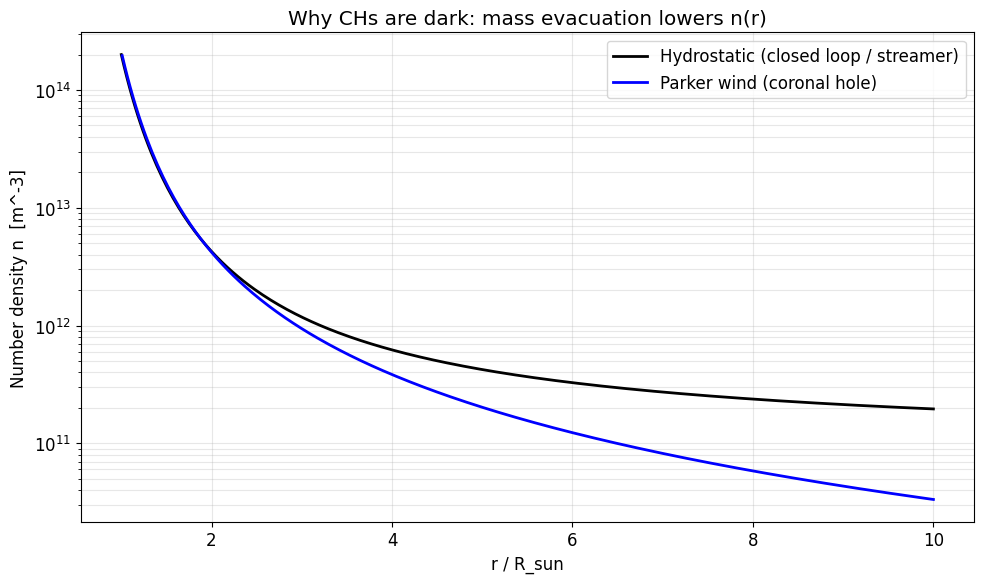

At r = 4.01 R_sun: n_hydro / n_wind = 1.6
Matches paper Fig. 5 showing streamers ~10x denser than coronal holes around 2-5 R_sun.
논문 Fig.5와 부합 — 2–5 R_sun 부근에서 streamer가 CH보다 ~10배 밀집.


In [5]:
T = 1.5e6
a = np.sqrt(2 * K_B * T / M_P)
n0 = 2e14  # base density, m^-3 (typical coronal base)

# Hydrostatic profile
r_hydro = np.linspace(1.0, 10, 300) * R_SUN
n_hydro = n0 * np.exp(-GM_SUN / a**2 * (1/R_SUN - 1/r_hydro))

# Parker wind profile: n*u*r^2 = n0*u0*R_sun^2
# take u(r=R_sun) from Parker solution
r_wind = np.linspace(1.01, 10, 300) * R_SUN
u_wind, rc, _ = parker_wind_solution(T, r_wind)
u0_interp = u_wind[0]  # u near the base
n_wind = n0 * (u0_interp / u_wind) * (R_SUN / r_wind)**2

fig, ax = plt.subplots()
ax.semilogy(r_hydro / R_SUN, n_hydro, 'k-', lw=2, label='Hydrostatic (closed loop / streamer)')
ax.semilogy(r_wind / R_SUN, n_wind, 'b-', lw=2, label='Parker wind (coronal hole)')
ax.set_xlabel('r / R_sun')
ax.set_ylabel('Number density n  [m^-3]')
ax.set_title('Why CHs are dark: mass evacuation lowers n(r)')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

ratio = n_hydro[100] / np.interp(r_hydro[100], r_wind, n_wind)
print(f'At r = {r_hydro[100]/R_SUN:.2f} R_sun: n_hydro / n_wind = {ratio:.1f}')
print('Matches paper Fig. 5 showing streamers ~10x denser than coronal holes around 2-5 R_sun.')
print('논문 Fig.5와 부합 — 2–5 R_sun 부근에서 streamer가 CH보다 ~10배 밀집.')

## Part 3: Flux-Tube Expansion vs. Wind Speed (Wang-Sheeley) / 자속관 발산 vs. 풍속

**English.** Wang & Sheeley (1990) found the empirical anti-correlation

$$ v_\infty \approx \frac{v_\mathrm{max}}{f_\mathrm{ss}^\alpha} + v_\mathrm{min} $$

where $f_\mathrm{ss}$ is the superradial expansion factor at the PFSS source surface, and $\alpha \sim 1$. Large polar CHs have small $f_\mathrm{ss}$ (expand nearly radially) → fast wind. Active-region–associated flux tubes have large $f_\mathrm{ss}$ → slow wind.

**한국어.** Wang-Sheeley(1990)의 경험적 역상관관계. $f_\mathrm{ss}$는 PFSS 원천 표면에서의 초발산률, $\alpha \sim 1$. 대형 극 CH는 작은 $f_\mathrm{ss}$(거의 방사 팽창) → 고속풍. 활동영역 자속관은 큰 $f_\mathrm{ss}$ → 저속풍.

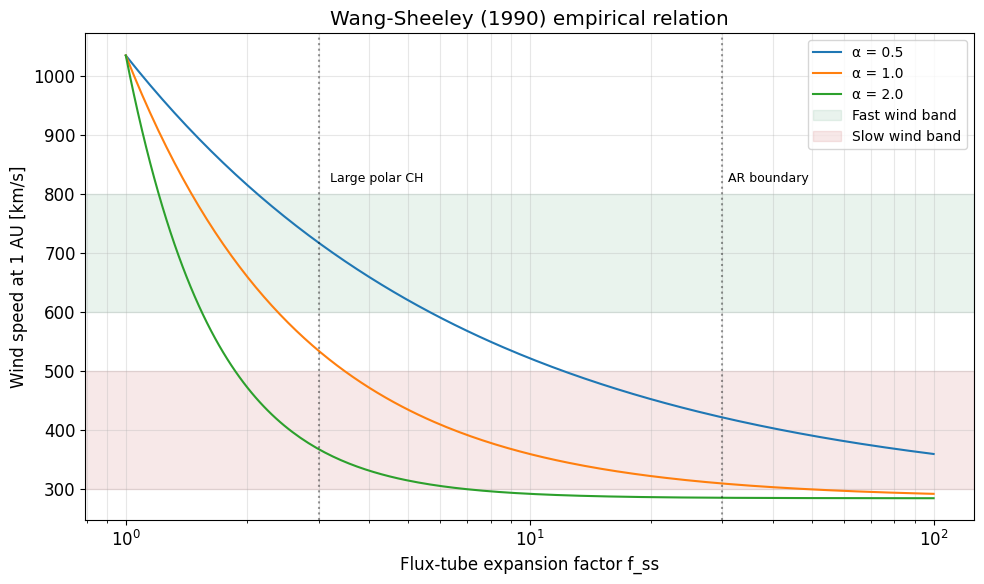

f_ss =    2: v_wind ≈ 660 km/s
f_ss =    5: v_wind ≈ 435 km/s
f_ss =   10: v_wind ≈ 360 km/s
f_ss =   30: v_wind ≈ 310 km/s


In [6]:
def wang_sheeley(f_ss, v_max=750.0, v_min=285.0, alpha=1.0):
    """Empirical Wang-Sheeley wind-speed vs. expansion-factor relation.

    Args:
        f_ss: expansion factor at source surface (>= 1).
        v_max: asymptotic fast-wind speed, km/s.
        v_min: asymptotic slow-wind baseline, km/s.
        alpha: power-law index.

    Returns:
        Wind speed at 1 AU, km/s.
    """
    return v_max / f_ss**alpha + v_min

f_ss_grid = np.geomspace(1, 100, 200)

fig, ax = plt.subplots()
for alpha in [0.5, 1.0, 2.0]:
    ax.plot(f_ss_grid, wang_sheeley(f_ss_grid, alpha=alpha), label=f'α = {alpha}')

# Mark example regions
ax.axhspan(600, 800, color='seagreen', alpha=0.1, label='Fast wind band')
ax.axhspan(300, 500, color='firebrick', alpha=0.1, label='Slow wind band')
ax.axvline(3, color='k', ls=':', alpha=0.4)
ax.text(3.2, 820, 'Large polar CH', fontsize=9)
ax.axvline(30, color='k', ls=':', alpha=0.4)
ax.text(31, 820, 'AR boundary', fontsize=9)

ax.set_xscale('log')
ax.set_xlabel('Flux-tube expansion factor f_ss')
ax.set_ylabel('Wind speed at 1 AU [km/s]')
ax.set_title('Wang-Sheeley (1990) empirical relation')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

for f in [2, 5, 10, 30]:
    print(f'f_ss = {f:4.0f}: v_wind ≈ {wang_sheeley(f):.0f} km/s')

## Part 4: Alfvén-Wave Energy Flux / Alfvén파 에너지 플럭스

**English.** The energy flux carried by outward-propagating Alfvén waves is

$$ F_A = \rho \langle \delta v^2 \rangle\, v_A \left(1 + \frac{u}{v_A}\right)^2 $$

where $\langle\delta v^2\rangle$ is the mean-square wave velocity amplitude. At the coronal base we need to sustain the wind kinetic energy plus radiative/conductive losses, typically $F_\mathrm{req} \sim 10^5~\mathrm{erg~cm^{-2}~s^{-1}} = 10^2~\mathrm{W/m^2}$. Photospheric G-band bright-point tracking gives $\delta v \sim 1$ km/s, and after expansion into the corona the amplitude grows roughly as $\rho^{-1/4}$ (WKB conservation of wave action).

**한국어.** 상향 Alfvén파의 에너지 플럭스는 위와 같음. $\langle\delta v^2\rangle$은 파 속도 요동의 제곱 평균. 코로나 기저에서 풍의 운동에너지와 복사·전도 손실을 충당하려면 $F_\mathrm{req} \sim 10^5$ erg cm⁻² s⁻¹ = $10^2$ W/m² 필요. 광구 bright-point 추적에서 $\delta v \sim 1$ km/s, 코로나 팽창 후 진폭은 대략 $\rho^{-1/4}$로 증가 (파 작용의 WKB 보존).

In [7]:
def alfven_wave_flux(rho, delta_v, B, u=0.0):
    """Compute outward Alfvén-wave energy flux (SI units).

    Args:
        rho: mass density, kg/m^3.
        delta_v: RMS wave velocity amplitude, m/s.
        B: magnetic field strength, T.
        u: bulk flow speed, m/s.

    Returns:
        Energy flux, W/m^2.
    """
    v_A = B / np.sqrt(MU_0 * rho)
    return rho * delta_v**2 * v_A * (1 + u / v_A)**2

# Photospheric base
rho_photo = 2e-4       # kg/m^3  (n_H ~ 1e17 /cm^3)
B_photo = 0.15         # T  (1500 G bright points)
dv_photo = 1e3         # m/s
F_photo = alfven_wave_flux(rho_photo, dv_photo, B_photo)

# Coronal base (CH)
rho_cor = 1e-13        # kg/m^3  (n_e ~ 1e8 /cm^3)
B_cor = 1e-4           # T  (1 G open field)
# Wave amplitude grows as rho^(-1/4): dv_cor / dv_photo = (rho_photo/rho_cor)^(1/4)
dv_cor = dv_photo * (rho_photo / rho_cor)**0.25
F_cor = alfven_wave_flux(rho_cor, dv_cor, B_cor)

F_required = 1e5 * 1e-3  # 10^5 erg/cm^2/s = 100 W/m^2

print('Photosphere: F_A ≈ {:.2e} W/m^2, δv ≈ {:.1f} km/s'.format(F_photo, dv_photo/1e3))
print('CH base:     F_A ≈ {:.2e} W/m^2, δv ≈ {:.1f} km/s'.format(F_cor, dv_cor/1e3))
print('Required for fast wind: ~{:.0f} W/m^2 (10^5 erg/cm^2/s)'.format(F_required))
print('\nInterpretation / 해석:')
print('The photospheric Alfvén flux is vastly more than enough — only a small fraction needs')
print('to survive the transition region and couple into the corona. WKB amplitude growth plus')
print('turbulent cascade dissipation together deliver the ~100 W/m^2 required.')
print('광구 Alfvén 플럭스는 필요량을 훨씬 초과 — 전이 영역을 지나 코로나로 결합하는 소수만 있으면 됨.')
print('WKB 진폭 증가와 난류 캐스케이드 소산이 함께 필요한 ~100 W/m²을 전달.')

Photosphere: F_A ≈ 1.89e+06 W/m^2, δv ≈ 1.0 km/s
CH base:     F_A ≈ 1.26e+03 W/m^2, δv ≈ 211.5 km/s
Required for fast wind: ~100 W/m^2 (10^5 erg/cm^2/s)

Interpretation / 해석:
The photospheric Alfvén flux is vastly more than enough — only a small fraction needs
to survive the transition region and couple into the corona. WKB amplitude growth plus
turbulent cascade dissipation together deliver the ~100 W/m^2 required.
광구 Alfvén 플럭스는 필요량을 훨씬 초과 — 전이 영역을 지나 코로나로 결합하는 소수만 있으면 됨.
WKB 진폭 증가와 난류 캐스케이드 소산이 함께 필요한 ~100 W/m²을 전달.


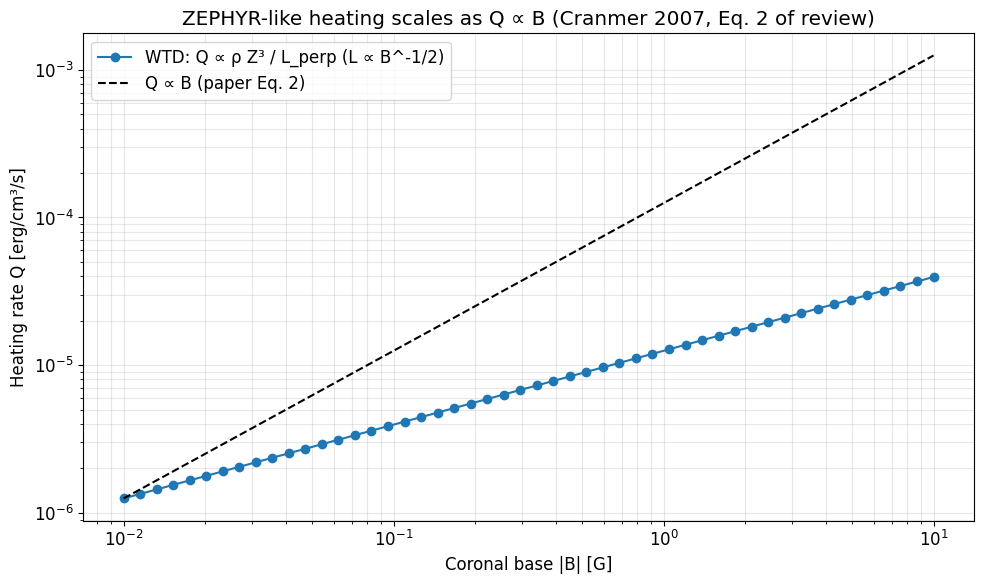

In [8]:
# ZEPHYR-inspired heating rate: Q ~ rho * Z^3 / L_perp
# Plot Q vs. B at the coronal base to verify the Q ∝ B scaling (Eq. 2 of paper)

def zephyr_heating(rho, Z, L_perp):
    """Simplified WTD heating rate (erg/cm^3/s).

    Args:
        rho: mass density, kg/m^3.
        Z: Elsässer amplitude, m/s.
        L_perp: perpendicular correlation length, m.

    Returns:
        Heating rate Q in W/m^3.
    """
    return rho * Z**3 / L_perp

B_base_range = np.geomspace(0.01, 10, 50) * 1e-4  # 0.01 G to 10 G in Tesla
rho_base = 1e-13

# L_perp ∝ B^{-1/2}
L_ref = 1e7  # reference ~1e7 m
B_ref = 1e-4
L_perp_vals = L_ref * (B_ref / B_base_range)**0.5

# Z ∝ rho^{-1/4}  but with rho fixed here, Z is fixed too
Z_base = 5e4  # ~50 km/s Elsässer amplitude at coronal base

Q_vals = zephyr_heating(rho_base, Z_base, L_perp_vals)

fig, ax = plt.subplots()
ax.loglog(B_base_range * 1e4, Q_vals * 1e1, 'o-', label='WTD: Q ∝ ρ Z³ / L_perp (L ∝ B^-1/2)')
# Reference scaling Q ∝ B
Q_ref = Q_vals[0] * 1e1
ax.loglog(B_base_range * 1e4, Q_ref * (B_base_range / B_base_range[0]), 'k--', label='Q ∝ B (paper Eq. 2)')
ax.set_xlabel('Coronal base |B| [G]')
ax.set_ylabel('Heating rate Q [erg/cm³/s]')
ax.set_title('ZEPHYR-like heating scales as Q ∝ B (Cranmer 2007, Eq. 2 of review)')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Part 5: Ion-Cyclotron Resonance Map / 이온-사이클로트론 공명 지도

**English.** Ion cyclotron frequency in SI is

$$ \Omega_i = \frac{q_i B}{m_i} = \frac{Z_i e}{A_i m_p}\, B $$

where $Z_i$ is charge number and $A_i$ is mass number. For resonance, parallel-propagating Alfvén waves must have $\omega = \Omega_i$ (in the ion rest frame). We map $(\omega, B)$ curves for the main UVCS-observed species: H⁺, O⁺⁵, Mg⁺⁹, Fe⁺¹². The $q/m$ ratio orders them; heavier/less-charged ions resonate at lower frequencies for a given $B$ — or equivalently, at larger heights where $B$ has dropped.

**한국어.** 이온 사이클로트론 주파수는 위와 같음. 공명을 위해 평행 전파 Alfvén파는 $\omega = \Omega_i$(이온 정지계). UVCS가 관측하는 주요 이온(H⁺, O⁺⁵, Mg⁺⁹, Fe⁺¹²)에 대해 $(\omega, B)$ 곡선을 그림. $q/m$이 이들을 배치 — 무겁거나 전하가 적은 이온은 주어진 $B$에서 낮은 주파수에서 공명 (또는 $B$가 감소한 더 큰 고도에서 공명).

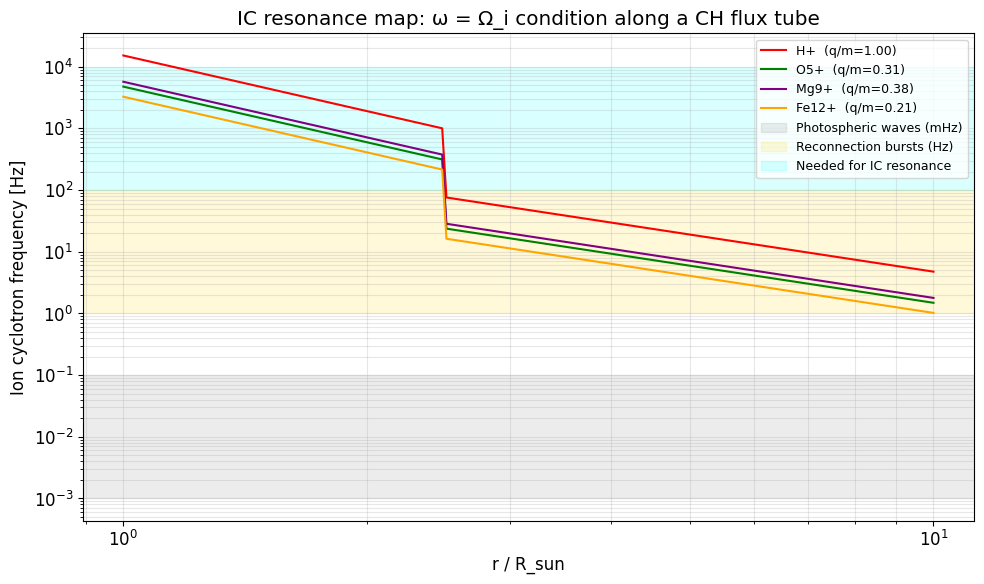

Note the frequency gap / 주파수 간극에 주목:
  Photospheric Alfvén waves (mHz) are 4–7 orders of magnitude below the gyrofrequencies.
  광구 Alfvén파(mHz)는 사이클로트론 주파수보다 4–7 자릿수 낮음.
  This is the crux of Cranmer §5.4: how do ions “find” resonant waves? Either reconnection
  produces high-freq waves locally (base generation), or a turbulent cascade bridges the gap
  (gradual generation). The paper argues this is still the central open question of CH physics.
  이것이 Cranmer §5.4의 핵심: 이온이 공명 파를 어떻게 "찾는가"? 재연결이 국소적으로 고주파 파를
  생성(기저 생성)하거나, 난류 캐스케이드가 간극을 잇는다(점진 생성). 논문은 이것이 여전히
  CH 물리의 핵심 미해결 쟁점이라고 주장.


In [9]:
def ion_cyclotron_freq(B, Z, A):
    """Ion cyclotron frequency (Hz, in SI).

    Args:
        B: magnetic field, T.
        Z: charge number (e.g., 5 for O^5+).
        A: mass number (e.g., 16 for O).

    Returns:
        Gyrofrequency in Hz (with 2*pi factor: cyclotron freq in rad/s / 2π).
    """
    Omega = Z * E_CHARGE * B / (A * M_P)
    return Omega / (2 * np.pi)

# B profile along open flux tube (rough dipole + source surface: B ~ B0 * (R_sun/r)^3 near surface,
# radial at large r: B ~ B_ss * (r_ss/r)^2)
r_over_R = np.linspace(1.0, 10, 300)
B_cor_base = 10e-4  # 10 G at base
B_ss = 5e-6         # 0.05 G at source surface
r_ss = 2.5
B_profile = np.where(
    r_over_R < r_ss,
    B_cor_base * (1 / r_over_R)**3,
    B_ss * (r_ss / r_over_R)**2
)

species = [
    ('H+',     1,  1, 'red'),
    ('O5+',    5, 16, 'green'),
    ('Mg9+',   9, 24, 'purple'),
    ('Fe12+', 12, 56, 'orange'),
]

fig, ax = plt.subplots()
for name, Z, A, c in species:
    freq = ion_cyclotron_freq(B_profile, Z, A)
    ax.loglog(r_over_R, freq, color=c, label=f'{name}  (q/m={Z/A:.2f})')

# Typical Alfvén wave frequency windows
ax.axhspan(1e-3, 1e-1, color='gray', alpha=0.15, label='Photospheric waves (mHz)')
ax.axhspan(1e0, 1e2, color='gold', alpha=0.15, label='Reconnection bursts (Hz)')
ax.axhspan(1e2, 1e4, color='cyan', alpha=0.15, label='Needed for IC resonance')

ax.set_xlabel('r / R_sun')
ax.set_ylabel('Ion cyclotron frequency [Hz]')
ax.set_title('IC resonance map: ω = Ω_i condition along a CH flux tube')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print('Note the frequency gap / 주파수 간극에 주목:')
print('  Photospheric Alfvén waves (mHz) are 4–7 orders of magnitude below the gyrofrequencies.')
print('  광구 Alfvén파(mHz)는 사이클로트론 주파수보다 4–7 자릿수 낮음.')
print('  This is the crux of Cranmer §5.4: how do ions “find” resonant waves? Either reconnection')
print('  produces high-freq waves locally (base generation), or a turbulent cascade bridges the gap')
print('  (gradual generation). The paper argues this is still the central open question of CH physics.')
print('  이것이 Cranmer §5.4의 핵심: 이온이 공명 파를 어떻게 "찾는가"? 재연결이 국소적으로 고주파 파를')
print('  생성(기저 생성)하거나, 난류 캐스케이드가 간극을 잇는다(점진 생성). 논문은 이것이 여전히')
print('  CH 물리의 핵심 미해결 쟁점이라고 주장.')

## Summary / 요약

| Concept / 개념 | This notebook / 이 노트북 | Modern tool / 현대 도구 |
|---|---|---|
| Parker wind solution | `parker_wind_solution` via `brentq` | SW-QSL / ZEPHYR / AWSoM / heliospheric MHD codes |
| Hydrostatic vs. wind density | Barometric law + mass conservation | Hansteen, PLUTO, Bifrost multi-D radiative MHD |
| Flux-tube expansion | Wang-Sheeley empirical $f_\mathrm{ss}$ | PFSS + MHD (ENLIL, EUHFORIA, SWMF) |
| Alfvén-wave flux | WKB $\delta v \propto \rho^{-1/4}$ | Non-WKB transport (Cranmer, van Ballegooijen 2005) |
| Ion cyclotron resonance | $\omega = \Omega_i$ map | PSP FIELDS wave measurements (in situ) |

### Key lesson / 핵심 교훈

**English.** No single simple equation explains the fast solar wind. The review's central point — borne out in every exercise above — is that **observations at different heights and via different diagnostics together constrain the problem uniquely**. Density profiles say "CHs are dark because mass escapes"; Parker solutions say "additional heating is required"; flux-tube expansion says "geometry matters"; Alfvén flux says "there's enough energy at the photosphere"; cyclotron maps say "but we need frequencies the photosphere doesn't provide." The WTD/RLO debate is a search for the mechanism that *bridges* these constraints.

**한국어.** 고속 태양풍을 단일한 간단한 방정식으로 설명할 수 없습니다. 리뷰의 핵심 요지 — 위 모든 연습에서 드러난 바 — 는 **서로 다른 고도와 서로 다른 진단에서의 관측이 함께 문제를 유일하게 제약**한다는 것입니다. 밀도 프로파일은 "질량이 탈출하기에 CH가 어둡다"고 말하고, Parker 해는 "추가 가열이 필요하다"고 말하며, 자속관 발산은 "기하가 중요하다"고, Alfvén 플럭스는 "광구에 에너지는 충분하다"고, 사이클로트론 지도는 "그런데 광구가 제공하지 않는 주파수가 필요하다"고 말합니다. WTD/RLO 논쟁은 이 모든 제약을 *잇는* 메커니즘의 탐색입니다.